In [98]:
# Carregamento das bibliotecas
import kagglehub
import os
import glob

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
import shap

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score, ConfusionMatrixDisplay
from xgboost import XGBClassifier

## Etapa 1: Definição do Problema de Negócio e Aquisição de Dados

In [80]:
# 1. Download automático do dataset via kagglehub
# O retorno é o caminho local onde os arquivos foram armazenados em cache.
path = kagglehub.dataset_download("mirbektoktogaraev/should-this-loan-be-approved-or-denied")
print(f"Dataset baixado em: {path}")

# Boa Prática: O dataset baixado pode conter vários arquivos. 
# Usamos a biblioteca glob para garantir que pegaremos o arquivo .csv exato,
# evitando "hardcodes" (nomes fixos) suscetíveis a falhas em atualizações futuras.
csv_files = glob.glob(os.path.join(path, "*.csv"))

if not csv_files:
    raise FileNotFoundError("Nenhum arquivo CSV foi encontrado no diretório especificado.")

csv_file_path = csv_files[0]
print(f"Arquivo selecionado para leitura: {csv_file_path}")

Dataset baixado em: C:\Users\ewert\.cache\kagglehub\datasets\mirbektoktogaraev\should-this-loan-be-approved-or-denied\versions\2
Arquivo selecionado para leitura: C:\Users\ewert\.cache\kagglehub\datasets\mirbektoktogaraev\should-this-loan-be-approved-or-denied\versions\2\SBAnational.csv


In [81]:
# 2. Carregamento e exploração inicial do dataset
"""
Ao carregar datasets não conhecidos inteiramente, é recomendável inspecionar os tipos. Usamos 'low_memory=False' ou tipagem
explícita para evitar warnings de Mixed Types comuns em datasets grandes
"""
# Carrega os dados no DataFrame
df = pd.read_csv(csv_file_path, low_memory=False)

# Visualizando as primeiras linhas do DataFrame
display(df.head())

,LoanNr_ChkDgt,Name,City,State,Zip,Bank,BankState,NAICS,ApprovalDate,ApprovalFY,...,RevLineCr,LowDoc,ChgOffDate,DisbursementDate,DisbursementGross,BalanceGross,MIS_Status,ChgOffPrinGr,GrAppv,SBA_Appv
0,1000014003,ABC HOBBYCRAFT,EVANSVILLE,IN,47711,FIFTH THIRD BANK,OH,451120,28-Feb-97,1997,...,N,Y,NaN,28-Feb-99,"$60,000.00",$0.00,P I F,$0.00,"$60,000.00","$48,000.00"
1,1000024006,LANDMARK BAR & GRILLE (THE),NEW PARIS,IN,46526,1ST SOURCE BANK,IN,722410,28-Feb-97,1997,...,N,Y,NaN,31-May-97,"$40,000.00",$0.00,P I F,$0.00,"$40,000.00","$32,000.00"
2,1000034009,"WHITLOCK DDS, TODD M.",BLOOMINGTON,IN,47401,GRANT COUNTY STATE BANK,IN,621210,28-Feb-97,1997,...,N,N,NaN,31-Dec-97,"$287,000.00",$0.00,P I F,$0.00,"$287,000.00","$215,250.00"
3,1000044001,"BIG BUCKS PAWN & JEWELRY, LLC",BROKEN ARROW,OK,74012,1ST NATL BK & TR CO OF BROKEN,OK,0,28-Feb-97,1997,...,N,Y,NaN,30-Jun-97,"$35,000.00",$0.00,P I F,$0.00,"$35,000.00","$28,000.00"
4,1000054004,"ANASTASIA CONFECTIONS, INC.",ORLANDO,FL,32801,FLORIDA BUS. DEVEL CORP,FL,0,28-Feb-97,1997,...,N,N,NaN,14-May-97,"$229,000.00",$0.00,P I F,$0.00,"$229,000.00","$229,000.00"


In [82]:
# 3. Função de extração do relatório de qualidade de dados
"""
Refatoração para encapsular lógicas analíticas em funcões modulares para facilitar a
reutilização em outros projetos de Machine Learning e permite teste isolados
"""

def gerar_relatorio_qualidade(dataframe: pd.DataFrame, target_col: str, output_file: str) -> None:
    """
    Gera um relatório descritivo sobre a qualidade do dataset para EDA
    Parâmetros:
        dataframe: pd.DataFrame a ser analisado
        target_col: Nome da coluna alvo (target) para o ML
        output_file: nome do arquivo .txt onde o ralatório será salvo
        """
    
    # 1. Tamanho do dataset
    linhas, colunas = dataframe.shape

    # 2. Tipos de dados, Contagem e % de valores nulos
    nulos_count = dataframe.isnull().sum()
    nulos_perc = (nulos_count / linhas) * 100
    tipos_dados = dataframe.dtypes

    # Criamos um DataFrame temporário para estruturar bem as informações das colunas
    df_info = pd.DataFrame({
        'Tipo de Dado': tipos_dados,
        'Valores Nulos': nulos_count,
        'Nulos (%)': nulos_perc.round(2)
    })

    # 3. Construindo as strings do relatório
    linhas_relatorio = [
        '----Relatório Inicial da qualidade dos dados---'
        f"\n[1] Dimensão do dataset",
        f" Total de linhas: {linhas}",
        f" Total de Colunas: {colunas}",
        "\n[2] Informações das colnas (Tipos e nulos):",
        df_info.to_string(),
        f"\n[3] Distribuição da variável alvo: '{target_col}'"
    ]

    if target_col in dataframe.columns:
        # Analisando a distribuição absoluta e relativa (%)
        dist_abs = dataframe[target_col].value_counts(dropna=False)
        dist_perc = dataframe[target_col].value_counts(normalize=True, dropna=False) * 100

        df_target = pd.DataFrame({
            'Quantidade': dist_abs,
            'Proporção (%)': dist_perc.round(2)
    })

        linhas_relatorio.append(df_target.to_string())
        linhas_relatorio.append("\n -> Nota: 'PIF' = Paid in Full (pago) | 'CHGOFF' = Charged off (Calote)")
    else:
        linhas_relatorio.append(f"\n -> ERRO: A coluna '{target_col}' não existe nesse dataset.")

    linhas_relatorio.append("=" * 60)

    # Unificando o conteúdo final
    texto_final = "\n".join(linhas_relatorio)

    # 4. Salvando em arquivo texto (uso do 'with' e codificação utf-8)
    with open(output_file, 'w', encoding='utf-8') as f:
        f.write(texto_final)

    print(f"Relatório ferado com sucesso e salvo em: {output_file}")

    # Print adificonal para visualização no jupyter
    print("\nVisualização do relatório gerado:")
    print(texto_final)

# Execução
gerar_relatorio_qualidade(dataframe=df,
                          target_col='MIS_Status',
                          output_file='relatorio_inicial_dados.txt')

Relatório ferado com sucesso e salvo em: relatorio_inicial_dados.txt

Visualização do relatório gerado:
----Relatório Inicial da qualidade dos dados---
[1] Dimensão do dataset
 Total de linhas: 899164
 Total de Colunas: 27

[2] Informações das colnas (Tipos e nulos):
                  Tipo de Dado  Valores Nulos  Nulos (%)
LoanNr_ChkDgt            int64              0       0.00
Name                       str             14       0.00
City                       str             30       0.00
State                      str             14       0.00
Zip                      int64              0       0.00
Bank                       str           1559       0.17
BankState                  str           1566       0.17
NAICS                    int64              0       0.00
ApprovalDate               str              0       0.00
ApprovalFY                 str              0       0.00
Term                     int64              0       0.00
NoEmp                    int64              0   

## Etapa 2: Limpeza de Dados e Feature Engineering

In [83]:
def standardize_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """
    Padroniza os nomes das colunas e os dados do tipo string
    Aplica o strip, lower e replace
    """
    df = df.copy()

    # 1. Padronização das colunas
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

    # 2. Padronização dos dados (apenas colunas do tipo object/string)
    str_cols = df.select_dtypes(include=['object', 'string', 'str']).columns
    for col in str_cols:
        df[col] = df[col].astype(str).str.strip().str.lower().str.replace(' ', '_')
        # Tratamento de segurança: ao converter para string, NaNs viram a string 
        df[col] = df[col].replace('nan', np.nan)

    return df 

In [84]:
def clean_sba_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Função principal de limpeza de dados para o dataset SBA Loans
    Executa a preparação e engenharia inicial das caracteristicas
    """
    # 0. Padronização geral 
    df = standardize_dataframe(df)

    # 1. Remoção de linhas sem a variável alvo (mis_status)
    # Não podemos treinar um modelo supervisionado sem o 'gabarito' 
    df = df.dropna(subset=['mis_status'])

    # 2. Conversão da variável alvo para numérico binário
    # Em ML, o evento de interesse (Risco/Calote) geralmente é mapeado como 1.
    target_mapping = {'chgoff': 1, 'p_i_f': 0}
    df['mis_status'] = df['mis_status'].map(target_mapping)

    # 3. Limpeza das colunas financeiras
    # Modelos matemáticos precisam de números (float), não de strings formatadas
    finance_cols = ['disbursementgross', 'balancegross', 'chgoffpringr', 'grappv', 'sba_appv']
    for col in finance_cols:
        if col in df.columns:
            df[col] = (df[col]
                       .str.replace('$', '', regex=False)
                       .str.replace(',', '', regex=False)
                       .astype(float))
            
    # 4. Tratamento de datas
    date_cols = ['approvaldate', 'disbursementdate']
    for col in date_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], format='%d-%b-%y', errors='coerce')

    # 5. Remoção da colunas com vazamento de dados ou irrelevantes
    cols_to_drop = ['loannr_chkdgt', 'name', 'chgoffdate']
    # erros='ignore' permite que o script continue mesmo se uma dessas colunas já não existir
    df = df.drop(columns=cols_to_drop, errors='ignore')

    # 6. Tratamento de valores nulos restantes
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    str_cols = df.select_dtypes(include=['object', 'string', 'str']).columns

    for col in numeric_cols:
        df[col] = df[col].fillna(df[col].median())

    for col in str_cols:
        df[col] = df[col].fillna('unknown')

    # 7. Verificação da variável alvo
    print("\n---Distribuição da Variável Alvo---")
    print(df['mis_status'].value_counts(dropna=False))    

    return df 

# Execução do Pipeline
if __name__ == "__main__":
    df_cleaned = clean_sba_data(df)
    display(df_cleaned.head())
    df_cleaned.info()
    pass


---Distribuição da Variável Alvo---
mis_status
0    739609
1    157558
Name: count, dtype: int64


,city,state,zip,bank,bankstate,naics,approvaldate,approvalfy,term,noemp,...,urbanrural,revlinecr,lowdoc,disbursementdate,disbursementgross,balancegross,mis_status,chgoffpringr,grappv,sba_appv
0,evansville,in,47711,fifth_third_bank,oh,451120,1997-02-28,1997,84,4,...,0,n,y,1999-02-28,60000.0,0.0,0,0.0,60000.0,48000.0
1,new_paris,in,46526,1st_source_bank,in,722410,1997-02-28,1997,60,2,...,0,n,y,1997-05-31,40000.0,0.0,0,0.0,40000.0,32000.0
2,bloomington,in,47401,grant_county_state_bank,in,621210,1997-02-28,1997,180,7,...,0,n,n,1997-12-31,287000.0,0.0,0,0.0,287000.0,215250.0
3,broken_arrow,ok,74012,1st_natl_bk_&_tr_co_of_broken,ok,0,1997-02-28,1997,60,2,...,0,n,y,1997-06-30,35000.0,0.0,0,0.0,35000.0,28000.0
4,orlando,fl,32801,florida_bus._devel_corp,fl,0,1997-02-28,1997,240,14,...,0,n,n,1997-05-14,229000.0,0.0,0,0.0,229000.0,229000.0


<class 'pandas.DataFrame'>
Index: 897167 entries, 0 to 899163
Data columns (total 24 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   city               897167 non-null  str           
 1   state              897167 non-null  str           
 2   zip                897167 non-null  int64         
 3   bank               897167 non-null  str           
 4   bankstate          897167 non-null  str           
 5   naics              897167 non-null  int64         
 6   approvaldate       897167 non-null  datetime64[us]
 7   approvalfy         897167 non-null  str           
 8   term               897167 non-null  int64         
 9   noemp              897167 non-null  int64         
 10  newexist           897167 non-null  float64       
 11  createjob          897167 non-null  int64         
 12  retainedjob        897167 non-null  int64         
 13  franchisecode      897167 non-null  int64         
 14  urba

In [85]:
# Salva o dataframe da memória para o disco
df_cleaned.to_csv('df_cleaned.csv', index=False)
print("Arquivo CSV gerado com sucesso!")

Arquivo CSV gerado com sucesso!


## Etapa 3: Análise Exploratória de Dados (EDA)

In [86]:
# 1. Configuração visual
"""
Definindo um tema global no seaborn garante consistência visual em todo o relatório.
Ignorar os warnings de depreciação do matplotlib/seaborn mantém o notebook limpo para apresentações executivas
"""
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette="muted")

df = pd.read_csv('df_cleaned.csv', parse_dates=['approvaldate', 'disbursementdate'])

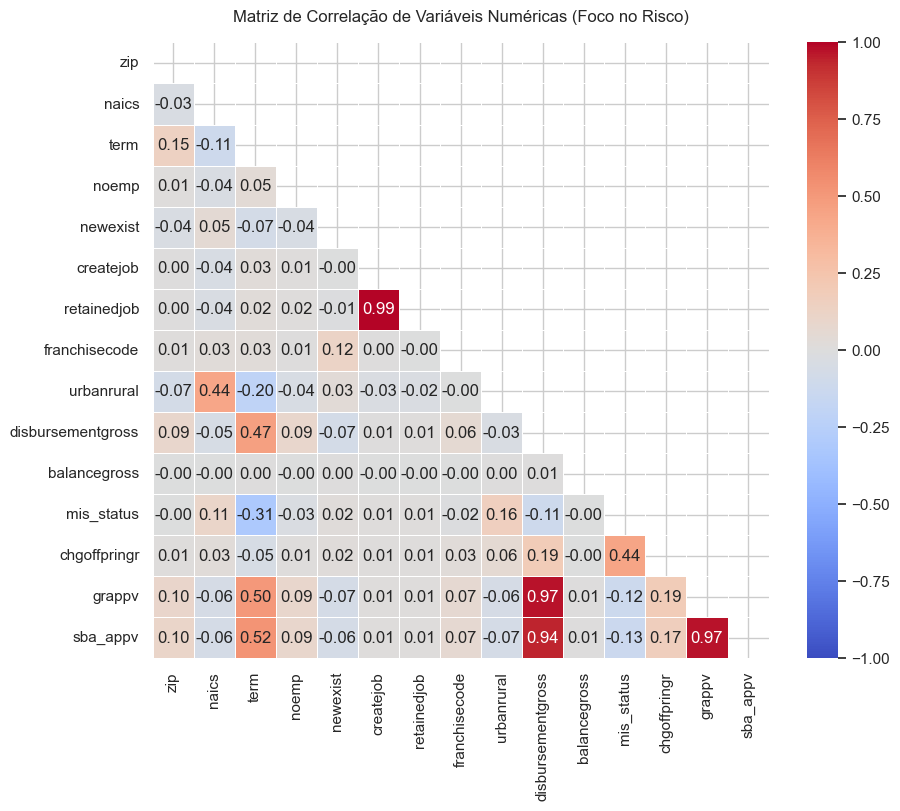

In [87]:
# 2. Matriz de correlação Linear
"""
Queremos ver quem tem a maior correlação (positiva ou negativa) com 'mis_status'
Variáveis muito correlacionadas entre si (ex: grappv e sba_appv) causam multicolinearidade,
o que pode instabilizar modelos lineares
"""

plt.figure(figsize=(10, 8))

# Filtrando apenas colunas numéricas de fomra segura
numeric_df = df.select_dtypes(include=[np.number])

# Calculando a correlação de Pearson
corr = numeric_df.corr()

# Máscara para esconder a metade superior da matriz (espelhada) e melhorar a legibilidade
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
            vmin=-1, vmax=1, square=True, linewidths=.5)

plt.title('Matriz de Correlação de Variáveis Numéricas (Foco no Risco)', pad=15)
plt.show()

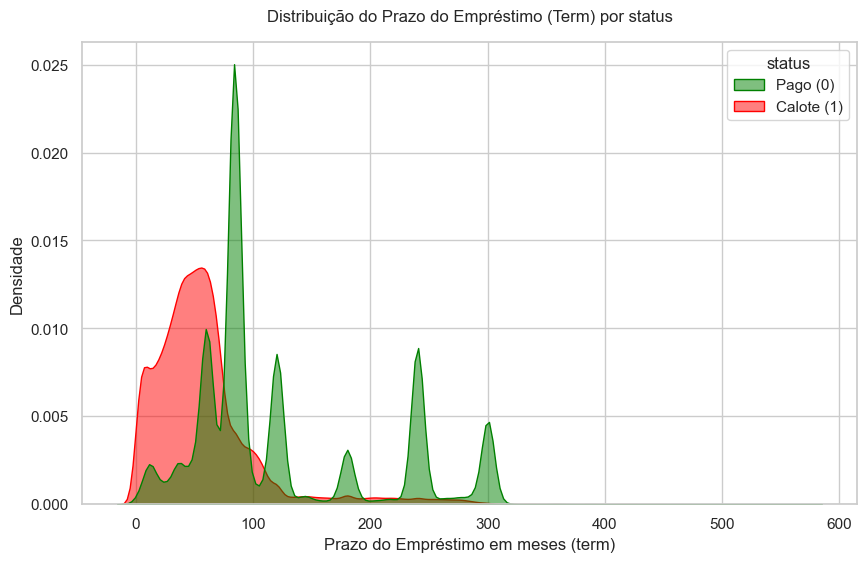

In [88]:
# 3. Distribuição de Risco pelo prazo do empréstimo (Term)
"""
O KDE (Kernel Density Estimation) ajuda a ver se há uma clara separação nas curvas
Se a curva vermelha (calote) tiver picos onde a verde não tem, significa que 'term' é uma excelente features preditiva para o modelo
"""

plt.figure(figsize=(10, 6))

# Mapeando os rótulos para a legenda em português
df_temp = df.copy()
df_temp['status'] = df_temp['mis_status'].map({0: 'Pago (0)', 1: 'Calote (1)'})

sns.kdeplot(data=df_temp, x='term', hue='status', common_norm=False, fill=True,
            palette=['green', 'red'], alpha=0.5)

plt.title('Distribuição do Prazo do Empréstimo (Term) por status', pad=15)
plt.xlabel('Prazo do Empréstimo em meses (term)')
plt.ylabel('Densidade')
plt.show()

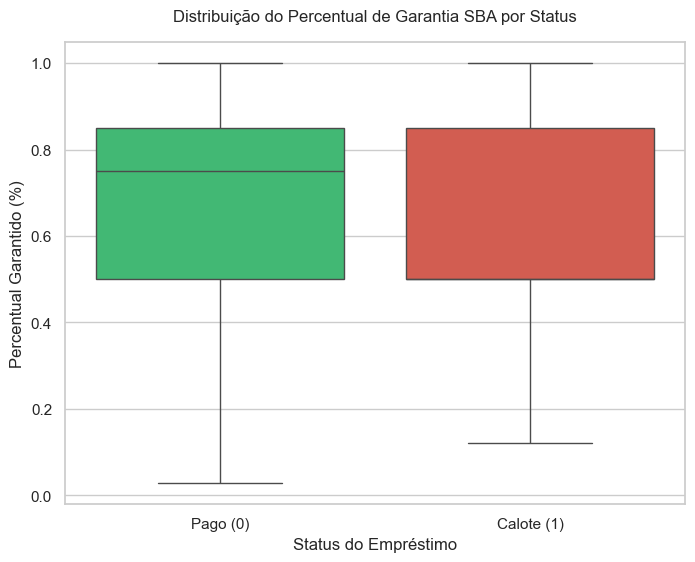

In [89]:
# 4. Impacto da garantia SBa (Feature Engineering)
"""
A Divisão direta pode gerar erro de divisão por zero, então usamos o np.where
para garantir que o grappv > 0
"""

# Criação da features: Quanto do valor bruto foi garantido pela SBA?
df['sba_guarantee_pct'] = np.where(df['grappv'] > 0,
                                   df['sba_appv'] / df['grappv'],
                                   0)

plt.figure(figsize=(8, 6))

sns.boxplot(data=df, x='mis_status', y='sba_guarantee_pct', palette=['#2ecc71', '#e74c3c'])

plt.title('Distribuição do Percentual de Garantia SBA por Status', pad=15)
plt.xticks(ticks=[0, 1], labels=['Pago (0)', 'Calote (1)'])
plt.xlabel('Status do Empréstimo')
plt.ylabel('Percentual Garantido (%)')
plt.show()

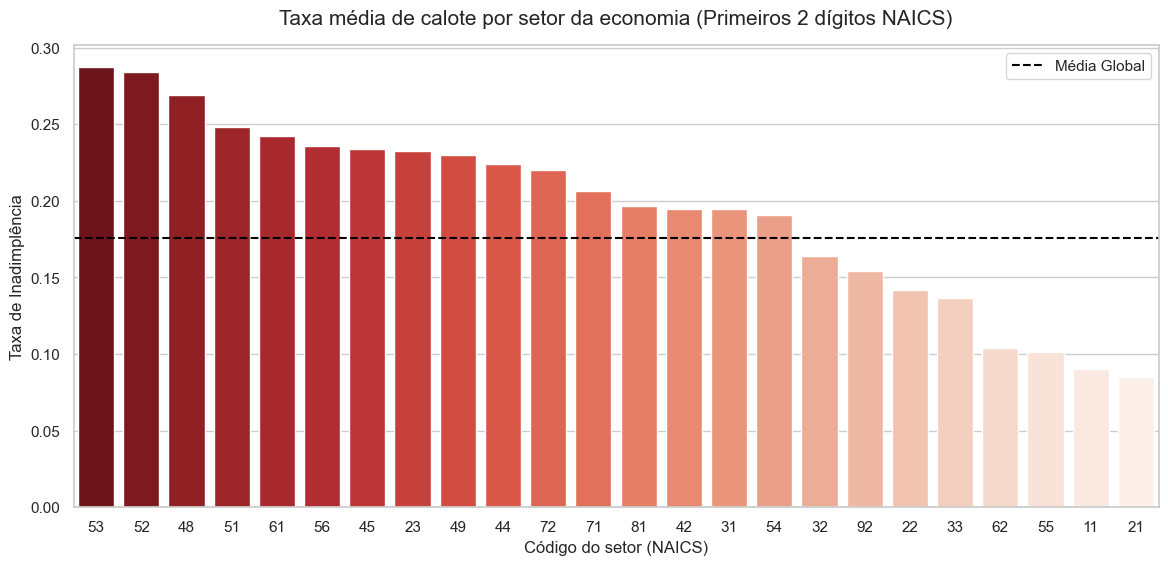

In [90]:
# 5. Extração do setor (NAICS) e Risco médio
"""
O código NAICS pode ter até 6 dígitos. Os 2 primeiros indicam o macro setor
Precisamos ignorar os '0' (não preenchidos) para não poluir a análise
"""

# Converte de forma segura removendo casas decimais (caso esteja como float)
df['naics_sector'] = df['naics'].astype(str).str.split('.').str[0].str[:2]

# Filtra valores desconhecidos (frequentemente representados por '0' ou menores que 2 chars)
df_naics = df[(df['naics_sector'] != '0') & (df['naics_sector'].str.len() == 2)]

# Agrupa calculando a média da variável alvo (isso nos dá a taxa de claote exata por setor)
sector_risk = df_naics.groupby('naics_sector')['mis_status'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(14, 6))
sns.barplot(data=sector_risk, x='naics_sector', y='mis_status', palette='Reds_r')

plt.title('Taxa média de calote por setor da economia (Primeiros 2 dígitos NAICS)', fontsize=15, pad=15)
plt.xlabel('Código do setor (NAICS)')
plt.ylabel('Taxa de Inadimplência')
plt.axhline(df['mis_status'].mean(), color='black', linestyle='--', label='Média Global')
plt.legend()
plt.show()

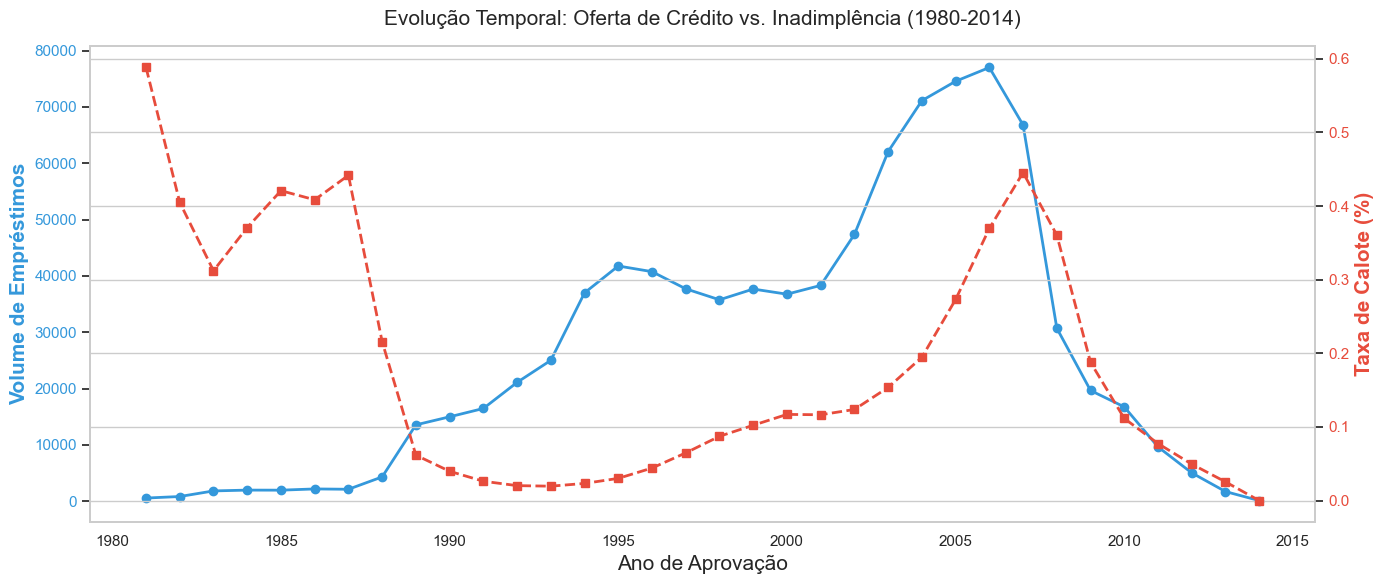

In [91]:
# 6. Volume vs Taxa de calote ao longo dos anos
"""
Aqui vamos usar um Twin Axis (eixo secundário) do matplotlib. Isso é essencial
porque o "volume" está na casa dos milhares e a "Taxa" está entre 0 e 1
"""

# Criação da features temporal
df['approval_year'] = df['approvaldate'].dt.year

# Agrupando métricas de contagem (volume) e média (taxa)
yearly_data = df.groupby('approval_year').agg(volume=('mis_status', 'count'),
                                              default_rate=('mis_status', 'mean')).reset_index()

# Filtrando anos duvidosos (ex: erros de digitação de 1900 ou futuros imrpováveis)
yearly_data = yearly_data[(yearly_data['approval_year'] > 1980) & (yearly_data['approval_year'] <= 2014)]

fig, ax1 = plt.subplots(figsize=(14, 6))

# Plotagem do Eixo 1 (Volume de Empréstimos)
color_vol = '#3498db'
ax1.set_xlabel('Ano de Aprovação', fontsize=15)
ax1.set_ylabel('Volume de Empréstimos', color=color_vol, fontweight='bold', fontsize= 15)
ax1.plot(yearly_data['approval_year'], yearly_data['volume'], color=color_vol, marker='o', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color_vol)
ax1.grid(False) # Desligamos o grid do eixo primário para não conflitar com o secundário

# Plotagem do Eixo 2 (Taxa de Calote)
ax2 = ax1.twinx()
color_rate = '#e74c3c'
ax2.set_ylabel('Taxa de Calote (%)', color=color_rate, fontweight='bold', fontsize=15)
ax2.plot(yearly_data['approval_year'], yearly_data['default_rate'], color=color_rate, marker='s', linestyle='--', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color_rate)

plt.title('Evolução Temporal: Oferta de Crédito vs. Inadimplência (1980-2014)', fontsize= 15, pad=15)
fig.tight_layout()
plt.show()

## Etapa 4 : Treinamento do Modelo (Machine Learning)

Desbalanceamento detectado, Usando scale_pos_weight = 4.69
Treinando o modelo XGBoost... (Isso pode levar alguns segundos)
Avaliação do modelo de risco de crédito
----------------------------------------

1. Classification Report:
              precision    recall  f1-score   support

     PIF (0)       0.96      0.97      0.96    147922
  CHGOFF (1)       0.86      0.79      0.82     31512

    accuracy                           0.94    179434
   macro avg       0.91      0.88      0.89    179434
weighted avg       0.94      0.94      0.94    179434

2. ROC-AUC Score: 0.9693
3. Precision-Recall AUC (PR-AUC): 0.8911


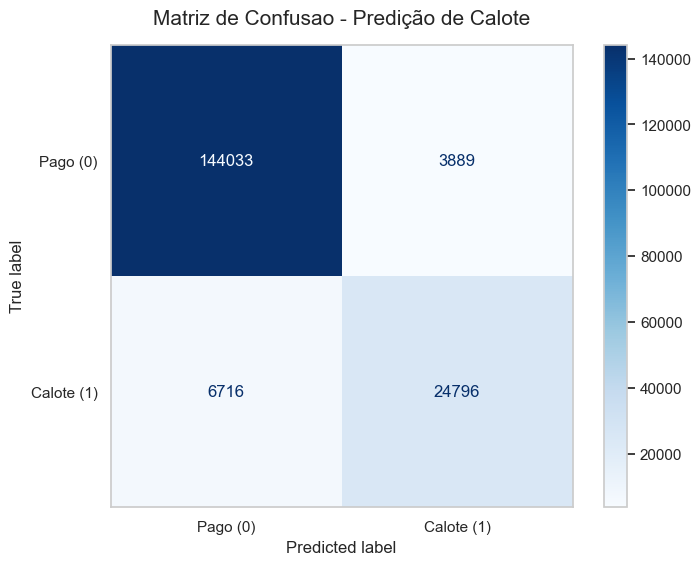

In [107]:
def train_credit_risk_model(df: pd.DataFrame, target_col: str = 'mis_status'):
    """
    Construindo o pipeline de pré=processamento, vamos treinar o xgBoost e avaliar o modelo
    """
    
    # 1. Definição de Variáveis
    num_features = ['term', 'grappv', 'sba_appv', 'sba_guarantee_pct', 'noemp']
    cat_features = ['state', 'bankstate', 'newexist', 'urbanrural', 'revlinecr']

    # Garantir que usamos apenas as colunas que importam
    features = num_features + cat_features
    X = df[features]
    y = df[target_col]

    # 2. Train-Test Split (Estratificando)
    # Stratify=y garante que a proporção de 0s e 1s seja mantida no treino e no teste
    X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                        test_size=0.20,
                                                        random_state=42,
                                                        stratify=y)
    
    # 3. Construção do pré-processador (ColumnTransformer)
    preprocessor = ColumnTransformer(transformers=[('num', StandardScaler(), num_features),
                                                   ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
                                                   ], remainder='drop') #Ignora colunas que não especificamos
    
    # 4. Tratamento de Desbalanceamento (scale_pos_weight)
    # Formula: contagem_classe_negativa / contagem_classe_positiva
    class_0_count = (y_train == 0).sum()
    class_1_count = (y_train == 1).sum()
    pos_weight = class_0_count / class_1_count

    print(f"Desbalanceamento detectado, Usando scale_pos_weight = {pos_weight:.2f}")

    # 5. Definição do Modelo (XGBoost)
    xgb_model = XGBClassifier(random_state=42,
                              scale_post_weight=pos_weight,
                              eval_metric='logloss',
                              use_label_encoder=False,
                              n_estimators=200,
                              max_depth=6,
                              learning_rate=0.1)
    
    # 6. Criação do Pipeline
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', xgb_model)])
    
    # 7. Treinamento
    print("Treinando o modelo XGBoost... (Isso pode levar alguns segundos)")
    pipeline.fit(X_train, y_train)

    # 8. Predições
    y_pred = pipeline.predict(X_test)
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1] # Probabilidades da classe 1

    print("Avaliação do modelo de risco de crédito")
    print("-"*40)

    # Relatório de Classificação
    print("\n1. Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['PIF (0)', 'CHGOFF (1)']))

    # Métricas de Área sob a Curva
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    pr_auc = average_precision_score(y_test, y_pred_proba)

    print(f"2. ROC-AUC Score: {roc_auc:.4f}")
    print(f"3. Precision-Recall AUC (PR-AUC): {pr_auc:.4f}")

    # Matriz de Confusão
    fig, ax = plt.subplots(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Pago (0)', 'Calote (1)'])
    disp.plot(cmap='Blues', values_format='d', ax=ax)
    plt.title("Matriz de Confusao - Predição de Calote", fontsize=15, pad=15)
    plt.grid(False)
    plt.show()

    return pipeline, X_train, X_test, y_train, y_test

modelo, X_train, X_test, y_train, y_test = train_credit_risk_model(df)

## Etapa 5: Explicabilidade e IA Generativa

Desacoplando o modelo e os dados do Pipeline
Calculando SHAP valeus... (isso pode demorar)


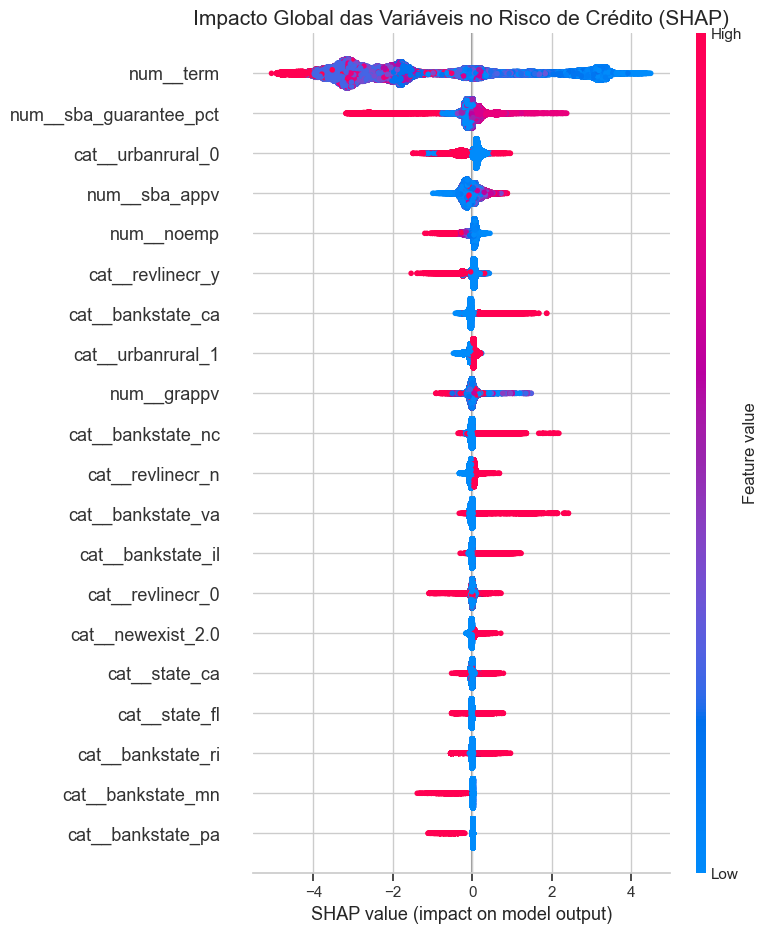


AUDITORIA INDIVIDUAL DO CLIENTE (ID Local: 93194)
Decisão do Modelo: Alto Risco (Calote Previsto) (Prob: 0.82)
Top 3 Fatores (SHAP Values):
 -> num__term (Puxou a decisão para Alto Risco)
 -> cat__bankstate_ny (Puxou a decisão para Alto Risco)
 -> cat__revlinecr_y (Puxou a decisão para Baixo Risco)

PROMPT GERADO PARA A API DA IA GENERATIVA
Atue como um consultor financeiro especialista em crédito para pequenas empresas.
Nosso modelo preditivo classificou o pedido de empréstimo deste cliente como: 'Alto Risco (Calote Previsto)'.

Os auditores do modelo (via valores SHAP) identificaram que os três fatores técnicos mais determinantes para essa pontuação exata foram:
[num__term (Puxou a decisão para Alto Risco) | cat__bankstate_ny (Puxou a decisão para Alto Risco) | cat__revlinecr_y (Puxou a decisão para Baixo Risco)]

Tarefa: Escreva um e-mail educado e empático para o empresário explicando o porquê desta decisão de crédito. Traduza as variáveis do sistema para a realidade de negócios d

In [ ]:
def analise_explicabilidade_shap(pipeline, X_test):
    """
    Desconstrói a 'caixa-preta' do pipeline XGBoost usando SHAP,
    gerando insights globais e locais
    """
    print("Desacoplando o modelo e os dados do Pipeline")

    # O SHAP opera sobre os números crus, precisamos extrair o transformador e o modelo de dentro do pipeline do Scikit-Learn
    preprocessor = pipeline.named_steps['preprocessor']
    xgb_model = pipeline.named_steps['classifier']

    # Transformando os dados de teste para o formato numérico/One-Hot
    X_test_transformed = preprocessor.transform(X_test)

    # Extraindo os nomes reais das colunas pós-transformação
    feature_names = preprocessor.get_feature_names_out()

    print("Calculando SHAP valeus... (isso pode demorar)")
    # 1. Usamos o TreeExplainer que é otimizado matematicamente para o XGBoost
    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_test_transformed)

    # 2. Gráfico de Impacto Global (Summary Plot)
    plt.figure(figsize=(10, 6))
    plt.title("Impacto Global das Variáveis no Risco de Crédito (SHAP)", fontsize= 15)
    shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, show=False)
    plt.tight_layout()
    plt.show()

    # 3. Explicação Local (Visão de um único cliente aleatório)
    # Seleciona um cliente específico para auditoria
    random_idx = np.random.randint(0, X_test_transformed.shape[0])
    instance = X_test_transformed[random_idx]
    instance_shap = shap_values[random_idx]

    # Predição da probabilidade para este cliente específico
    prob_pred = xgb_model.predict_proba(instance.reshape(1, -1))[0, 1]
    predicao_str = "Alto Risco (Calote Previsto)" if prob_pred > 0.5 else "Baixo Risco (Aprovação Prevista)"

    # Extraindo os 3 principais fatores que influenciaram esta decisão
    # argsort(), pega os índices dos menores para os maiores, 0 [::-1] inverte a ordem
    top_indices = np.argsort(np.abs(instance_shap))[-3:][::-1]

    top_fatores = []
    for i in top_indices:
        nome_var = feature_names[i]
        valor_shap = instance_shap[i]
        impacto = "Puxou a decisão para Alto Risco" if valor_shap > 0 else "Puxou a decisão para Baixo Risco"
        top_fatores.append(f"{nome_var} ({impacto})")

    return random_idx, prob_pred, predicao_str, top_fatores

def gerar_relatorio_ia(fatores: list, predicao: str) -> str:
    """
    Essa função constrói um prompt parametrizado para envio a uma API de IA Generativa
    O objetivo é traduzir o array matemático do SHAP em linguagem de negócios
    """
    fatores_formatados = " | ".join(fatores)
    
    prompt = (
        f"Atue como um consultor financeiro especialista em crédito para pequenas empresas.\n"
        f"Nosso modelo preditivo classificou o pedido de empréstimo deste cliente como: '{predicao}'.\n\n"
        f"Os auditores do modelo (via valores SHAP) identificaram que os três fatores "
        f"técnicos mais determinantes para essa pontuação exata foram:\n"
        f"[{fatores_formatados}]\n\n"
        f"Tarefa: Escreva um e-mail educado e empático para o empresário explicando o porquê "
        f"desta decisão de crédito. Traduza as variáveis do sistema para a realidade de negócios dele, "
        f"não use jargões de Machine Learning (como 'SHAP' ou 'One-Hot'), e dê dicas práticas de "
        f"como ele pode melhorar seu perfil de crédito perante o banco."
    )
    return prompt

# Executa as análises do SHAP
idx_cliente, prob, pred_str, fatores_chave = analise_explicabilidade_shap(modelo, X_test)

# Mostra o caso local no console
print("\n" + "="*60)
print(f"Auditoria Individual do Cliente (ID Local: {idx_cliente})")
print("="*60)
print(f"Decisão do Modelo: {pred_str} (Prob: {prob:.2f})")
print("Top 3 Fatores (SHAP Values):")
for f in fatores_chave:
    print(f" -> {f}")

# Gera o prompt para a LLM
prompt_llm = gerar_relatorio_ia(fatores_chave, pred_str)
print("\n" + "="*60)
print("Prompt Gerado Para a API da IA Generativa")
print("="*60)
print(prompt_llm)